In [1]:
%load_ext autoreload
%autoreload 2
from data_handling import *
import xarray as xr 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import gaussian_kde as kde
import sys, os
# from get_ddf import *
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import * 
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.8',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.4',
                'lemon_creek':'58.5_-134.4',
                'gulkana':'63.5_-145.6'}
site_dict = {'wolverine':['N','B','EC'],
                'kahiltna':['K53','K17b'], # took out K14k because it's too high --- wind redistribution probably crucial here
                'kennicott':['GTL','GTH','KC31'],
                'lemon_creek':['B','C','D'],
                'taku':['NWB1','TKG3'],
                'gulkana':['AU','B','D'] # 'B','MG1',
                }

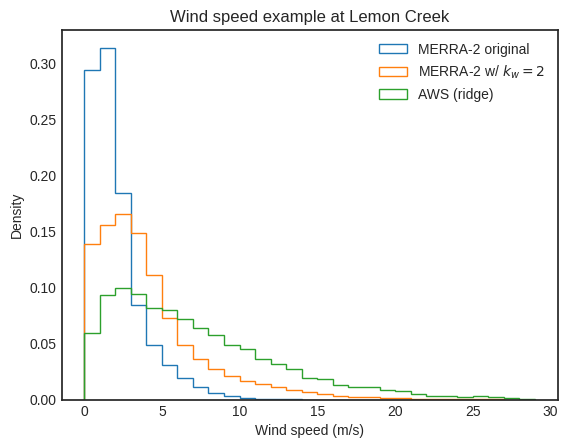

In [17]:
u = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/58.5_-134.4/U2M_58.5_-134.4.nc')
v = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/58.5_-134.4/U2M_58.5_-134.4.nc')

df = pd.read_csv('/trace/group/rounce/cvwilson/climate_data/benchmark/lemonCreek/LVL2/lemoncreek1285_hourly_LVL2.csv')

w = np.sqrt(np.square(u.values) + np.square(v.values))
bins = np.arange(0, 30, 1)
plt.hist(w, histtype='step', bins=bins, label='MERRA-2 original', density=True)
plt.hist(w*2, histtype='step', bins=bins, label='MERRA-2 w/ $k_w=2$', density=True)
plt.hist(df['WindSpeed'].values, histtype='step', bins=bins, label='AWS (ridge)', density=True)
plt.legend()
plt.ylabel('Density')
plt.xlabel('Wind speed (m/s)')
plt.title('Wind speed example at Lemon Creek')
plt.show()

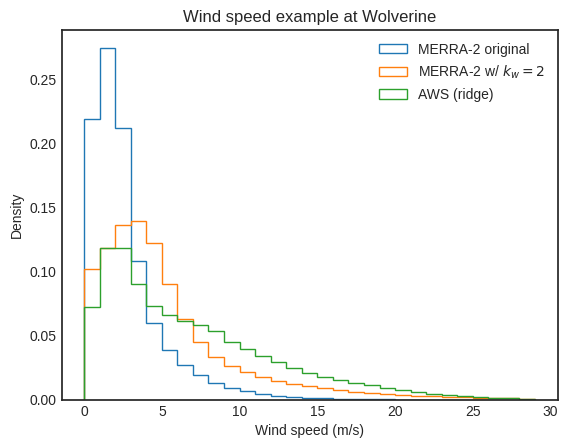

In [12]:
u = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/60.5_-148.8/U2M_60.5_-148.8.nc')
v = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/60.5_-148.8/U2M_60.5_-148.8.nc')

df = pd.read_csv('/trace/group/rounce/cvwilson/climate_data/benchmark/wolverine/LVL2/wolverine990_hourly_LVL2.csv')

w = np.sqrt(np.square(u.values) + np.square(v.values))
bins = np.arange(0, 30, 1)
plt.hist(w, histtype='step', bins=bins, label='MERRA-2 original', density=True)
plt.hist(w*2, histtype='step', bins=bins, label='MERRA-2 w/ $k_w=2$', density=True)
plt.hist(df['WindSpeed'].values, histtype='step', bins=bins, label='AWS (ridge)', density=True)
plt.legend()
plt.ylabel('Density')
plt.xlabel('Wind speed (m/s)')
plt.title('Wind speed example at Wolverine')
plt.show()

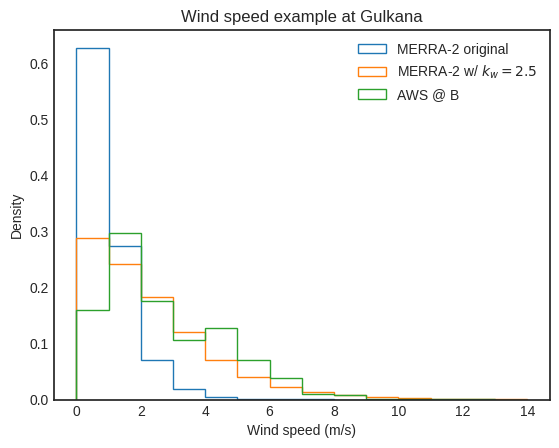

In [41]:
u = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/63.5_-145.6/U2M_63.5_-145.6.nc')
v = xr.open_dataarray('/trace/group/rounce/cvwilson/climate_data/MERRA2/63.5_-145.6/U2M_63.5_-145.6.nc')

df = pd.read_csv('/trace/home/cvwilson/research/climate_data/AWS/Processed/gulkana2024.csv')

w = np.sqrt(np.square(u.values) + np.square(v.values))
bins = np.arange(0, 15, 1)
plt.hist(w, histtype='step', bins=bins, label='MERRA-2 original', density=True)
plt.hist(w*2.5, histtype='step', bins=bins, label='MERRA-2 w/ $k_w=2.5$', density=True)
plt.hist(df['uwind'].values, histtype='step', bins=bins, label='AWS @ B', density=True)
plt.legend()
plt.ylabel('Density')
plt.xlabel('Wind speed (m/s)')
plt.title('Wind speed example at Gulkana')
plt.show()

In [18]:
fp = '/trace/group/rounce/cvwilson/rs/albedo/updated/'
for glacier in site_dict:
    num = translate_rgi[glacier]['7'][3:]
    ds = xr.open_dataset(fp + f'{num}/RGI2000-v7.0-G-01-{num}_l9.nc')
    print(glacier, 'count of glacier mask:', ds['dem_shadow_mask'].sum().values)

wolverine count of glacier mask: 1647
kahiltna count of glacier mask: 47806
kennicott count of glacier mask: 0
lemon_creek count of glacier mask: 0
taku count of glacier mask: 0
gulkana count of glacier mask: 0


In [18]:
wind_factors = [1, 1.5, 2, 2.5, 3, 3.5]

fn = 'ddf/calibrate_wind/grid_{g}_{s}_windfactor{w}_0.nc'
all_mod_albedo = []
all_meas_albedo = []
all_time_albedo = []
best_dict = {}
all_best = {}
only = False # 'good'
snow_only = True
for glacier in site_dict:
    best_dict[glacier] = {}
    all_best[glacier] = {}
    for site in site_dict[glacier]:
        best = np.inf 
        for wind_factor in wind_factors:
            fn_ds = base_fp + fn.format(g=glacier, s=site, w=wind_factor)
            try:
                ds = xr.open_dataset(fn_ds)
                assert ds.melt.sum() != 0
            except:
                continue

            albedo_data = Albedo(glacier, site, use='all')
            albedo_data.get_model_albedo(ds, snow_only=snow_only)
            mb_data = MassBalance(glacier, site, use='benchmark')
            mb_data.get_model_mb(ds)

            if mb_data.dataset == 'seasonal':
                error , _= mb_data.mae(True)
            else:
                error = mb_data.mae()

            if error < best:
                best = error 
                best_ds = ds
                best_wind = wind_factor

        albedo_data = Albedo(glacier, site, use='all')
        albedo_data.get_model_albedo(best_ds, snow_only=snow_only)
        mb_data = MassBalance(glacier, site, use='benchmark')
        mb_data.get_model_mb(best_ds)
        print(glacier, site, 'wind factor of',best_wind)
        best_dict[glacier][site] = best_wind
        
        # if mb_data.dataset == 'seasonal':
        #     mae_summer, mae_winter = mb_data.mae(True)
        #     print('Summer mass balance MAE:',mae_summer)
        #     print('Winter mass balance MAE:',mae_winter)

        #     me_summer, me_winter = mb_data.bias(True)
        #     print('Summer mass balance bias:',me_summer)
        #     print('Winter mass balance bias:',me_winter)
        # else:
        #     print('Annual mass balance MAE:',mb_data.mae())
        #     print('Annual mass balance bias', mb_data.bias())

        for mod, meas, t in zip(albedo_data.mod, albedo_data.meas, albedo_data.time):
            all_mod_albedo.append(mod)
            all_meas_albedo.append(meas)
            all_time_albedo.append(t)

        # plot
        # fig, ax = mb_data.plot_mb()
        # ax.set_title(f'{glacier} {site} with wind factor {best_wind}')
        # plt.savefig(base_fp + f'../figs/ddf/calibration/{glacier+site}_best_mb.png')
        # plt.show()
        # plt.close()
        
        # albedo_data.plot_timeseries()
        # albedo_data.plot_1to1()
        # albedo_data.plot_map('2019-08-20',full=True, savefig=True)


wolverine N wind factor of 1.5
wolverine B wind factor of 1.5
wolverine EC wind factor of 1.5
kahiltna K53 wind factor of 1
kahiltna K17b wind factor of 1
kennicott GTL wind factor of 2


TypeError: 'float' object is not iterable

In [2]:
import pickle
if os.path.exists('best_wind.pkl'):
    with open('best_wind.pkl', 'rb') as f:
        best_dict = pickle.load(f)
else:
    with open('best_wind.pkl', 'wb') as f:
        pickle.dump(best_dict, f)
best_dict

{'wolverine': {'N': 1.5, 'B': 1.5, 'EC': 1.5},
 'kahiltna': {'K53': 1, 'K17b': 1},
 'kennicott': {'GTL': 2, 'GTH': 3.5, 'KC31': 1.5},
 'lemon_creek': {'B': 1.5, 'C': 1.5, 'D': 2},
 'taku': {'NWB1': 1.5, 'TKG3': 1},
 'gulkana': {'AU': 1.5, 'B': 2, 'D': 2}}

In [ ]:
# # TROUBLESHOOTING FIGURE: ALBEDO TIMESERIES IN EACH YEAR FOR EACH GLACIER 
# plot = False
# snow_only = False 
# deltas = True 
# fn = 'ddf/grid_{g}_{s}_windfactor{w}_0.nc'

# glaciers = ['gulkana','kennicott', 'wolverine', 'lemon_creek', 'kahiltna']
# sites = [['B','D'], ['GTL','GTH'], ['N','EC'], ['B','D'], ['K53','K17b']]
# all_meas_albedo = [] 
# all_mod_albedo = []
# all_time_albedo = []

# for (g, (site1, site2)) in zip(glaciers, sites):
#     # load datasets
#     ds1 = xr.open_dataset(base_fp + fn.format(g=g, s=site1, w=best_dict[g][site1]))
#     ds2 = xr.open_dataset(base_fp + fn.format(g=g, s=site2, w=best_dict[g][site2]))

#     # get observations
#     a1 = Albedo(g, site1)
#     a2 = Albedo(g, site2)

#     # process model
#     a1.get_model_albedo(ds1, snow_only=snow_only)
#     a2.get_model_albedo(ds2, snow_only=snow_only)
#     if deltas:
#         a1.get_deltas()
#         a2.get_deltas()
#     for a in [a1, a2]:
#         for meas, mod, t in zip(a.meas, a.mod, a.time):
#             all_meas_albedo.append(meas)
#             all_mod_albedo.append(mod)
#             all_time_albedo.append(t)

#     if plot:
#         years = np.arange(2019, 2025)
#         fig, axes = plt.subplots(2, 3, figsize=(8, 6), gridspec_kw={'hspace':0.3, 'wspace': 0.3})
#         axes = axes.flatten()
#         for yr, ax in zip(years, axes):
#             dates = pd.date_range(f'{yr}-04-01',f'{yr}-08-20')

#             for i, a in enumerate([a1, a2]):
#                 time, mod, meas = a.get_dates(dates)
#                 if i == 0: ax.scatter(time, meas, label='Satellite')
#                 else: ax.scatter(time, meas)
#                 ax.plot(time, mod, label=site)

#             # if g == 'gulkana':
#             #     if yr == 2024:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkana2024_walbedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[pd.date_range(f'{yr}-04-20',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             #     elif yr == 2025:
#             #         df = pd.read_csv('../../climate_data/AWS/Processed/gulkanaB2025_albedo.csv', parse_dates=True, index_col=0)
#             #         df = df.loc[df.index.hour.isin(range(13, 15))].resample('d').mean()
#             #         df = df.loc[pd.date_range(f'{yr}-04-23',f'{yr}-08-20')]
#             #         ax.plot(df.index, df['albedo'], label='AWS', c=plt.cm.tab10(0), linestyle=':')

#             # ax.set_xlim(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'))
#             ax.set_xticks(pd.date_range(pd.to_datetime(f'{yr}-04-20'), pd.to_datetime(f'{yr}-08-20'), freq='2MS'))
#             ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%Y'))
#             ax.minorticks_on()
#             ax.tick_params(length=5)
#         ax.legend()
#         name = ' '.join(g.split('_')).capitalize()
#         fig.suptitle(name, y=0.93)
#         plt.savefig(base_fp + f'../figs/ddf/albedo_comparison_{g}.png', bbox_inches='tight')
#         plt.show()

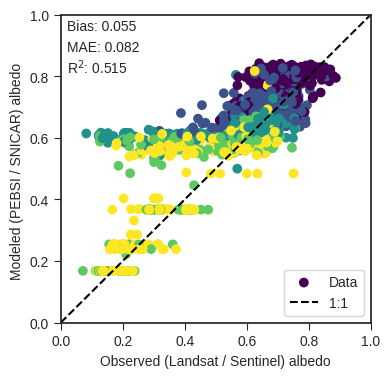

In [16]:
fn = 'ddf/{g}{s}_2026_05_08_base_0.nc'
all_meas_albedo = [] 
all_mod_albedo = []
all_time_albedo = []
deltas = False
snow_only = False

for glacier in site_dict:
    for site in site_dict[glacier]:    
        ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
        assert ds.melt.sum() > 0, 'did not save'
        albedo = Albedo(glacier, site)
        albedo.get_model_albedo(ds, snow_only=snow_only)
        if deltas:
            albedo.get_deltas()

        for meas, mod, t in zip(albedo.meas, albedo.mod, albedo.time):
            all_meas_albedo.append(meas)
            all_mod_albedo.append(mod)
            all_time_albedo.append(t)

fig, ax = plt.subplots(figsize=(4, 4))
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=4, vmax=8)

ax.scatter(all_meas_albedo, all_mod_albedo, label='Data', c=cmap(norm(pd.to_datetime(all_time_albedo).month)))
if deltas:
    minval, maxval = -0.7, 0.02
else:
    minval, maxval = 0, 1
ax.plot([minval, maxval],[minval, maxval],'k--',label='1:1')

meas = np.array(all_meas_albedo).ravel()
mod = np.array(all_mod_albedo).ravel()
bias = np.nanmean(mod - meas)
mae = np.nanmean(np.abs(meas - mod))
r2 = 1 - np.sum(np.square(meas - mod)) / np.sum(np.square(meas - np.mean(meas)))
ax.text(0.02, 0.95, f'Bias: {bias:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.88, f'MAE: {mae:.3f}', transform=ax.transAxes)
ax.text(0.02, 0.81, f'R$^2$: {r2:.3f}', transform=ax.transAxes)

ax.legend(frameon=True)
ax.set_xlim(minval, maxval)
ax.set_ylim(minval, maxval)
ax.tick_params(length=5)
if not deltas:
    ax.set_ylabel('Modeled (PEBSI / SNICAR) albedo ')
    ax.set_xlabel('Observed (Landsat / Sentinel) albedo')
else:
    ax.set_ylabel('$\Delta$ Modeled (PEBSI / SNICAR) albedo')
    ax.set_xlabel('$\Delta$ Observed (Landsat / Sentinel) albedo')
deltastr = '_deltas' if deltas else ''
plt.savefig(f'/trace/group/rounce/cvwilson/figs/ddf/albedo{deltastr}.png', bbox_inches='tight', dpi=300)
plt.show()

taku TKG3 ['2020-09-29T00:00:00.000000000' '2020-09-30T00:00:00.000000000'
 '2020-10-01T00:00:00.000000000' '2020-10-02T00:00:00.000000000'
 '2020-10-03T00:00:00.000000000']
kahiltna K53 ['2015-05-09T00:00:00.000000000' '2015-05-10T00:00:00.000000000'
 '2015-05-11T00:00:00.000000000' '2015-05-12T00:00:00.000000000'
 '2015-05-13T00:00:00.000000000']
lemon_creek B ['2020-09-25T00:00:00.000000000' '2020-09-26T00:00:00.000000000'
 '2020-09-27T00:00:00.000000000' '2020-09-28T00:00:00.000000000']
lemon_creek C ['2020-10-04T00:00:00.000000000' '2020-10-05T00:00:00.000000000'
 '2020-10-06T00:00:00.000000000' '2020-10-07T00:00:00.000000000'
 '2020-10-08T00:00:00.000000000']


/tmp/ipykernel_517294/1571522312.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


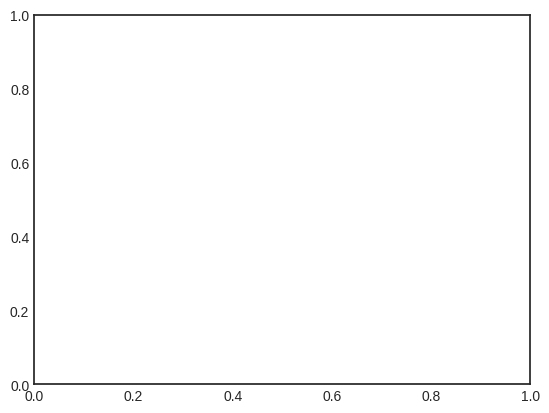

In [66]:
glacier, site = 'wolverine','B'
for glacier in ['taku','kahiltna', 'lemon_creek']:
    for site in site_dict[glacier]:
        ds = xr.open_dataset(base_fp + 'ddf/{g}{s}_2026_05_08_base_0.nc'.format(g=glacier, s=site))
        snow_depth = ds['layerheight'].where(ds['layertype'] < 1).sum(dim='layer').resample(time='1d').min()

        dsa = ds.albedo.sel(time=pd.date_range(ds.time.values[0], ds.time.values[-1]))
        dsa = dsa.where(snow_depth > 0.05)
        # plt.hist(ds.values, label=glacier+site)
        time_weird = dsa.where(dsa < 0.45, drop=True).time.values[:5]
        if len(time_weird) > 0:
            k = ds.sel(time=time_weird)
            print(glacier, site, time_weird)
            # print(k.snowdepth.values, k.firndepth.values, k.albedo.values)
plt.legend()

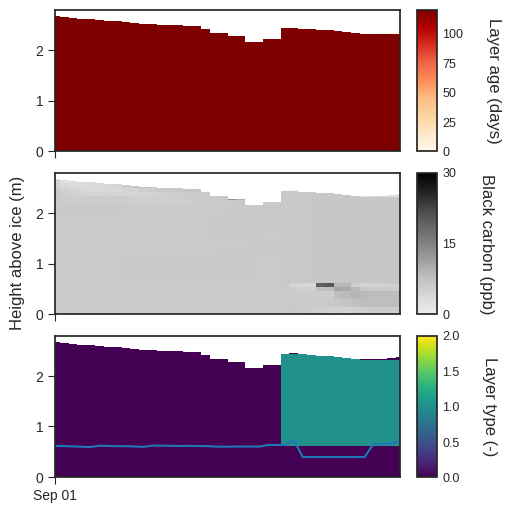

In [64]:
visualize_layers(ds, pd.date_range('2020-09-01', '2020-10-10'), ['layerage','layerBC','layertype'])
ga = ds.sel(time=pd.date_range('2020-09-01', '2020-10-10'))
plt.plot(ga.time, ga.albedo)

In [ ]:

# albedo.plot_1to1()
# for year in range(2019, 2025):
#     albedo.plot_timeseries(years=[year])

In [43]:
glacier, site = 'taku','Taku-1'
ds = xr.open_dataset(base_fp + fn.format(g=glacier, s=site))
ds = ds.sel(time=slice('2016-07-18','2016-07-19'), layer=0).max(dim='time')
print('TAKU')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')

l = LAPs(site)
print('Measured BC', l.bc_july, 'Measured dust', l.dust_july)
print()

glacier, site = 'gulkana','D'
ds = xr.open_dataset(base_fp + fn.replace('ratios3','test').format(g=glacier, s=site))

ds = ds.sel(time=slice('2024-08-21','2024-08-22'), layer=0).max(dim='time')
print(f'PEBSI BC {ds.layerBC.values:.1f}    PEBSI dust {ds.layerdust.values:.1f}    PEBSI Albedo {ds.albedo.values:.3f}')
print('Measured BC between 2.9 and 10.5', 'Measured dust between 121-262')

TAKU
PEBSI BC 12.6    PEBSI dust 33.3    PEBSI Albedo 0.570
Measured BC 6.9 Measured dust 25

PEBSI BC 5.1    PEBSI dust 0.5    PEBSI Albedo 0.706
Measured BC between 2.9 and 10.5 Measured dust between 121-262


In [ ]:
#######################################################################################